# Olist preprocessing — exploration & validation

Walks through the raw Olist tables, runs `src.data.preprocess` with our default
settings, and validates that the resulting `data/processed/orders.csv` is
suitable input for the simulator.

Run this after placing the Kaggle CSVs in `data/raw/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make `src.*` importable when the notebook is launched from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)

## 1. Inspect the raw tables

We only need orders + items + products to build the demand signal.

In [2]:
from src.data.preprocess import load_raw

tables = load_raw(PROJECT_ROOT / 'data' / 'raw')
for name, df in tables.items():
    print(f'{name:>10} -> shape={df.shape}')

    orders -> shape=(99441, 8)
     items -> shape=(112650, 7)
  products -> shape=(32951, 9)
   sellers -> shape=(3095, 4)


In [3]:
orders = tables['orders']
print('Date range:', orders['order_purchase_timestamp'].min(), '->', orders['order_purchase_timestamp'].max())
print()
print(orders['order_status'].value_counts())

Date range: 2016-09-04 21:15:19 -> 2018-10-17 17:30:18

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Olist's earliest few orders are isolated trial transactions from late 2016 — the platform really got going in early 2017. Visualising daily volume makes the dead window obvious.

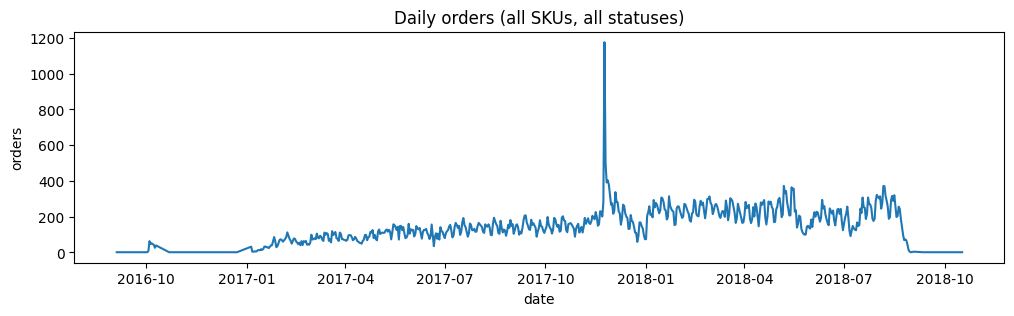

In [4]:
daily = (
    orders.assign(date=orders['order_purchase_timestamp'].dt.date)
    .groupby('date').size().rename('orders')
)
ax = daily.plot(figsize=(12, 3), title='Daily orders (all SKUs, all statuses)')
ax.set_ylabel('orders'); ax.set_xlabel('date');

## 2. Run preprocessing with the agreed defaults

Daily granularity, top-200 SKUs by total units, all non-cancelled statuses,
windowed to 2017-01-01 → 2018-08-31.

In [5]:
from src.data.preprocess import PreprocessConfig, build_demand_table, write_processed

cfg = PreprocessConfig(
    raw_dir=PROJECT_ROOT / 'data' / 'raw',
    out_path=PROJECT_ROOT / 'data' / 'processed' / 'orders.csv',
    top_n_skus=200,
    granularity='D',
    min_date='2017-01-01',
    max_date='2018-08-31',
)
demand = build_demand_table(tables, cfg)
write_processed(demand, cfg.out_path)
print(f'Rows: {len(demand):,}  SKUs: {demand.sku.nunique()}  Steps: {demand.step.max() + 1}  Total qty: {int(demand.qty.sum()):,}')
demand.head()

Rows: 12,900  SKUs: 200  Steps: 594  Total qty: 19,870


,step,sku,qty
0,0,777d2e438a1b645f3aec9bd57e92672c,1
1,2,6cdd53843498f92890544667809f1595,1
2,4,6cdd53843498f92890544667809f1595,1
3,5,6cdd53843498f92890544667809f1595,1
4,5,a50acd33ba7a8da8e9db65094fa990a4,1


## 3. Validate the demand signal

**a)** Coverage — almost every step should have at least one event.

In [6]:
per_step = (
    demand.groupby('step')['qty'].sum()
    .reindex(range(demand['step'].max() + 1), fill_value=0)
)
n_steps = len(per_step)
active = (per_step > 0).sum()
print(f'Steps:        {n_steps}')
print(f'With demand:  {active} ({100 * active / n_steps:.1f}%)')
print(f'Zero days:    {(per_step == 0).sum()}')
print()
print(per_step.describe().round(1))

Steps:        594
With demand:  589 (99.2%)
Zero days:    5

count    594.0
mean      33.5
std       24.0
min        0.0
25%       17.0
50%       29.5
75%       44.0
max      288.0
Name: qty, dtype: float64


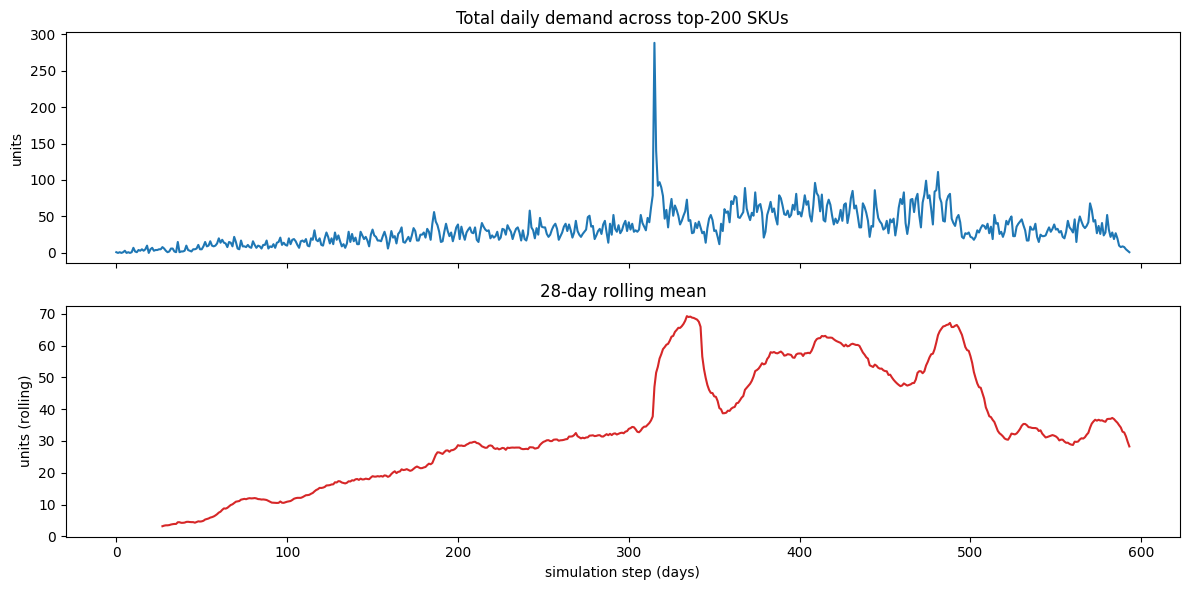

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
per_step.plot(ax=axes[0], title='Total daily demand across top-200 SKUs', color='#1f77b4')
axes[0].set_ylabel('units')
per_step.rolling(28).mean().plot(ax=axes[1], title='28-day rolling mean', color='#d62728')
axes[1].set_ylabel('units (rolling)')
axes[1].set_xlabel('simulation step (days)')
plt.tight_layout();

Two things to notice in the rolling mean:

1. **Underlying growth trend** — daily demand rises from ~5 units/day in early 2017 to ~50 units/day by late 2018. This is real platform growth; it looks a lot like the *gradual drift* scenario the thesis asks us to evaluate.
2. **Black Friday spike (Nov 2017)** — the visible weekly bump near step ~320 is real seasonality. It already approximates the *seasonal pulse* scenario.

**b)** SKU distribution — confirm the head/tail isn't pathological.

count    200.0
mean      99.4
std       79.4
min       45.0
25%       55.0
50%       71.0
75%      108.8
max      527.0
Name: qty, dtype: float64

Top SKU total units: 527
Tail SKU total units: 45


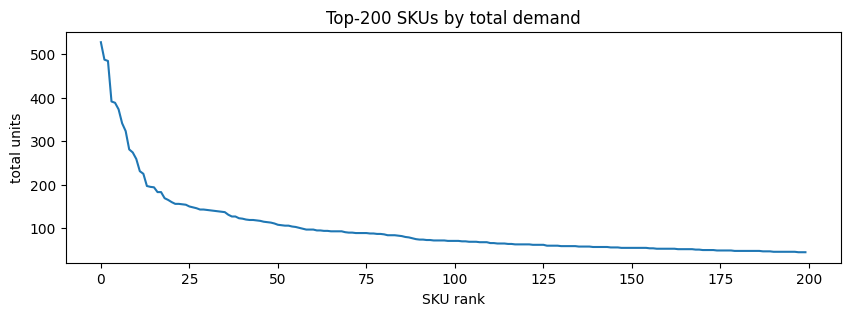

In [8]:
per_sku = demand.groupby('sku')['qty'].sum().sort_values(ascending=False)
print(per_sku.describe().round(1))
print()
print(f'Top SKU total units: {per_sku.iloc[0]}')
print(f'Tail SKU total units: {per_sku.iloc[-1]}')
ax = per_sku.reset_index(drop=True).plot(figsize=(10, 3), title='Top-200 SKUs by total demand')
ax.set_xlabel('SKU rank'); ax.set_ylabel('total units');

## 4. Build a sensible initial-stock dict for the simulator

Pre-load each SKU with roughly 30 days of mean demand. That's enough buffer
for early steps before the replenishment loop kicks in.

In [9]:
mean_per_sku_per_day = demand.groupby('sku')['qty'].sum() / (demand['step'].max() + 1)
initial_stock = (mean_per_sku_per_day * 30).round().astype(int).clip(lower=10)
print(f'Total starting units: {int(initial_stock.sum()):,}')
print(initial_stock.describe().round(0))

Total starting units: 2,102


count    200.0
mean      11.0
std        2.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       27.0
Name: qty, dtype: float64


## 5. Smoke-run the simulator on this data

Confirm the processed CSV plugs into the existing pipeline without further edits.

In [10]:
from src.simulation import InventoryModel, OrderReplay, DriftInjector

replay = OrderReplay.from_csv(cfg.out_path)
model = InventoryModel(
    skus=replay.skus,
    replay=replay,
    drift_injector=DriftInjector(scenarios=[]),
    initial_stock=initial_stock.to_dict(),
    seed=42,
)
summary = model.run(n_steps=replay.n_steps)
summary

/Users/bisry/Documents/IF/inventory-mas/.venv/lib/python3.14/site-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


{'n_steps': 594,
 'stockout_rate': 0.04040404040404041,
 'stockout_duration_per_sku': {'0a57f7d2c983bcf8188589a5fea4a8da': 1,
  '389d119b48cf3043d311335e499d9c6b': 1,
  '53759a2ecddad2bb87a079a1f1519f73': 2,
  'b5e13c9a353102f79c6206ff5cb61a50': 1,
  'aca2eb7d00ea1a7b8ebd4e68314663af': 3,
  '54d9ac713e253fa1fae9c8003b011c2a': 4,
  '5411e9269501a870cabf632f05655131': 2,
  '3f14d740544f37ece8a9e7bc8349797e': 1,
  '437c05a395e9e47f9762e677a7068ce7': 1,
  '962a6951154f98f2c8e9a5b8b2bcf4a9': 1,
  '53b36df67ebb7c41585e8d54d6772e08': 4,
  '2fea0f2cec6b6324a277d4a61c2ed2c6': 1,
  'e7cc48a9daff5436f63d3aad9426f28b': 1},
 'final_total_on_hand': 9171}

## 6. Open questions for the next iteration

- The 4x growth in `final_total_on_hand` vs starting stock confirms the **replenishment policy is over-ordering**. The current `order_up_to = ROP + mean_lt_demand` is a placeholder. Tightening this (proper EOQ, safety stock from forecast variance) is the next obvious step on the agent-design side.
- Even without injected drift, the **organic growth trend** in the rolling mean means a static-ROP baseline should naturally degrade in the back half of the run — useful for the comparative evaluation.
- 200 SKUs gives ~33 events/day on average. For the scalability hypothesis (H3) we should also generate `top-500` and `top-1000` variants and time the run-loop.